## 0. Install Dependencies & Imports

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
# Install any missing packages
!pip install -q wordcloud contractions gensim

import os, re, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter

import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize

from wordcloud import WordCloud

from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay

import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (Embedding, SimpleRNN, LSTM,
                                     Dense, Dropout, SpatialDropout1D)
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

import gensim.downloader as gensim_api

warnings.filterwarnings("ignore")

for pkg in ["stopwords", "wordnet", "punkt", "punkt_tab", "omw-1.4"]:
    nltk.download(pkg, quiet=True)

SEED = 42
tf.random.set_seed(SEED)
np.random.seed(SEED)

print("All imports successful.")
print(f"TensorFlow version: {tf.__version__}")


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 79.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 345.1/345.1 kB 37.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 13.2 MB/s eta 0:00:00
All imports successful.
TensorFlow version: 2.20.0


### Text Preprocessing, Tokenization & Sequence Padding

### Load & Inspect Dataset

Train : 35,000 rows
Test  : 10,000  rows
Val   : 5,000   rows
Total : 50,000  labeled rows

Class distribution (combined):
sentiment
Negative (0)    25000
Positive (1)    25000
Name: count, dtype: int64


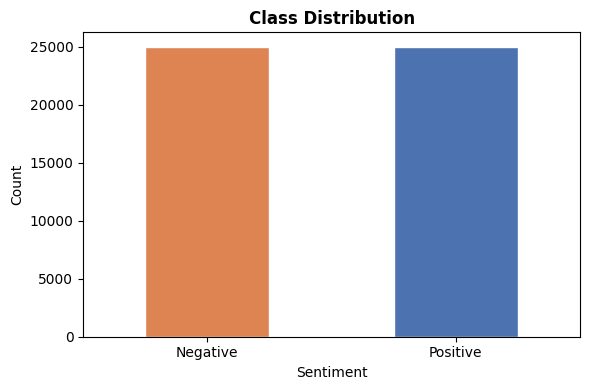

In [4]:
def load_split(path):
    df = pd.read_csv(path)
    # Drop unlabeled rows (keep only 0 and 1)
    df = df.dropna(subset=["sentiment"])
    df = df[df["sentiment"].isin([0, 1])].reset_index(drop=True)
    df["sentiment"] = df["sentiment"].astype(int)
    return df

df_train = load_split("/content/drive/MyDrive/coursewook/5. Movie Review Dataset/train_movie_review.csv")
df_test  = load_split("/content/drive/MyDrive/coursewook/5. Movie Review Dataset/test_movie_review.csv")
df_val   = load_split("/content/drive/MyDrive/coursewook/5. Movie Review Dataset/val_movie_review.csv")
df_full  = pd.concat([df_train, df_test, df_val], ignore_index=True)

print(f"Train : {len(df_train):,} rows")
print(f"Test  : {len(df_test):,}  rows")
print(f"Val   : {len(df_val):,}   rows")
print(f"Total : {len(df_full):,}  labeled rows\n")
print("Class distribution (combined):")
print(df_full["sentiment"].value_counts().rename({0:"Negative (0)", 1:"Positive (1)"}))
df_full.head()


fig, ax = plt.subplots(figsize=(6, 4))
df_full["sentiment"].value_counts().rename({0: "Negative", 1: "Positive"}).plot(
    kind="bar", ax=ax, color=["#DD8452", "#4C72B0"], edgecolor="white"
)
ax.set_title("Class Distribution", fontweight="bold")
ax.set_xlabel("Sentiment")
ax.set_ylabel("Count")
ax.set_xticklabels(["Negative", "Positive"], rotation=0)
plt.tight_layout()
plt.show()


### Clean Text

In [5]:
CONTRACTIONS = {
    "don't":"do not","doesn't":"does not","didn't":"did not","won't":"will not",
    "can't":"cannot","couldn't":"could not","shouldn't":"should not",
    "wouldn't":"would not","isn't":"is not","aren't":"are not",
    "wasn't":"was not","weren't":"were not","haven't":"have not",
    "hasn't":"has not","hadn't":"had not","i'm":"i am","i've":"i have",
    "i'll":"i will","i'd":"i would","you're":"you are","you've":"you have",
    "you'll":"you will","you'd":"you would","he's":"he is","she's":"she is",
    "it's":"it is","we're":"we are","they're":"they are","they've":"they have",
    "they'll":"they will","that's":"that is","what's":"what is",
    "here's":"here is","there's":"there is","let's":"let us",
    "'ve":" have","'re":" are","'ll":" will","'d":" would","n't":" not",
}

stop_words = set(stopwords.words("english"))

# Keep negation words — critical for sentiment analysis
negation_words = {"not", "no", "never", "nor", "neither", "nothing",
                  "nowhere", "nobody", "none", "cannot", "without"}
stop_words = stop_words - negation_words

lemmatizer = WordNetLemmatizer()

def expand_contractions(text):
    for k, v in CONTRACTIONS.items():
        text = text.replace(k, v)
    return text

def clean_text(text):
    text = str(text).lower()
    text = expand_contractions(text)
    text = re.sub(r"http\S+|www\S+", " ", text)   # URLs
    text = re.sub(r"@\w+", " ", text)               # mentions
    text = re.sub(r"#\w+", " ", text)               # hashtags
    text = re.sub(r"\d+", " ", text)                # numbers
    text = re.sub(r"[^a-z\s]", " ", text)           # special chars
    tokens = word_tokenize(text)
    tokens = [lemmatizer.lemmatize(t) for t in tokens
              if t not in stop_words and len(t) > 1]
    return " ".join(tokens)

print("Cleaning text — this may take a minute…")
df_full["clean_review"] = df_full["review"].apply(clean_text)
print("Cleaning complete.")
print("\nSample before/after:")
for i in range(2):
    print(f"\n[{i+1}] ORIGINAL : {df_full['review'].iloc[i][:120]}...")
    print(f"    CLEANED  : {df_full['clean_review'].iloc[i][:120]}...")

Cleaning text — this may take a minute…
Cleaning complete.

Sample before/after:

[1] ORIGINAL : Having avoided seeing the movie in the cinema, but buying the DVD for my wife for Xmas, I had to watch it. I did not exp...
    CLEANED  : avoided seeing movie cinema buying dvd wife xmas watch not expect much usually mean get bargained mamma mia utter utter ...

[2] ORIGINAL : With this movie I was really hoping that the idea was to make up for the hashed together ineptitude of the first AVP, an...
    CLEANED  : movie really hoping idea make hashed together ineptitude first avp yet horror requiem far worse could imagined br br hop...


### Visualise Cleaned Data

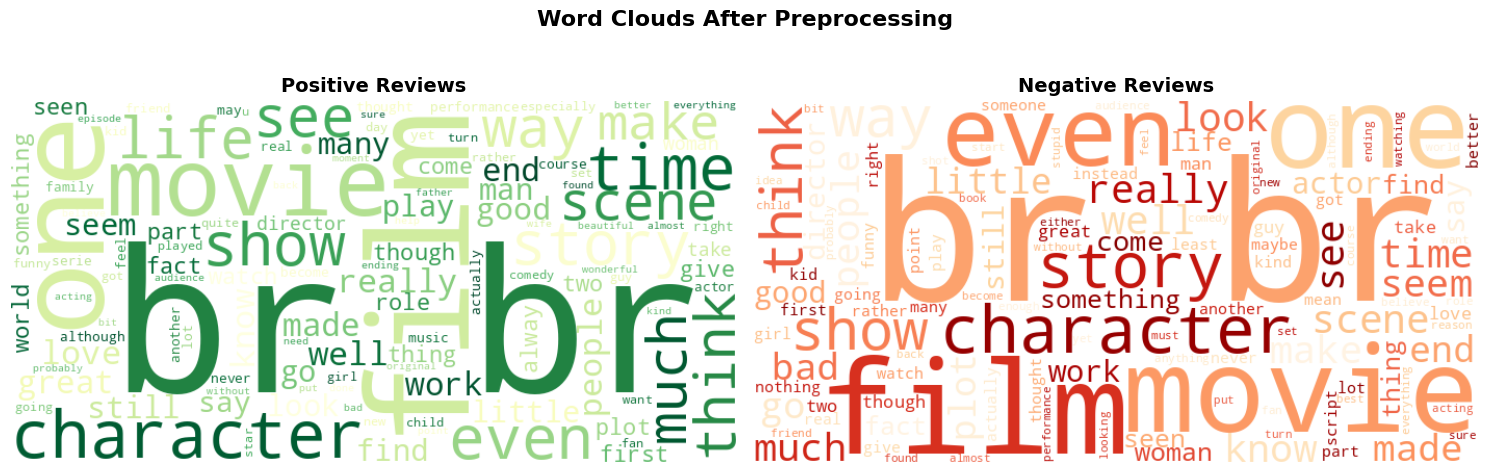

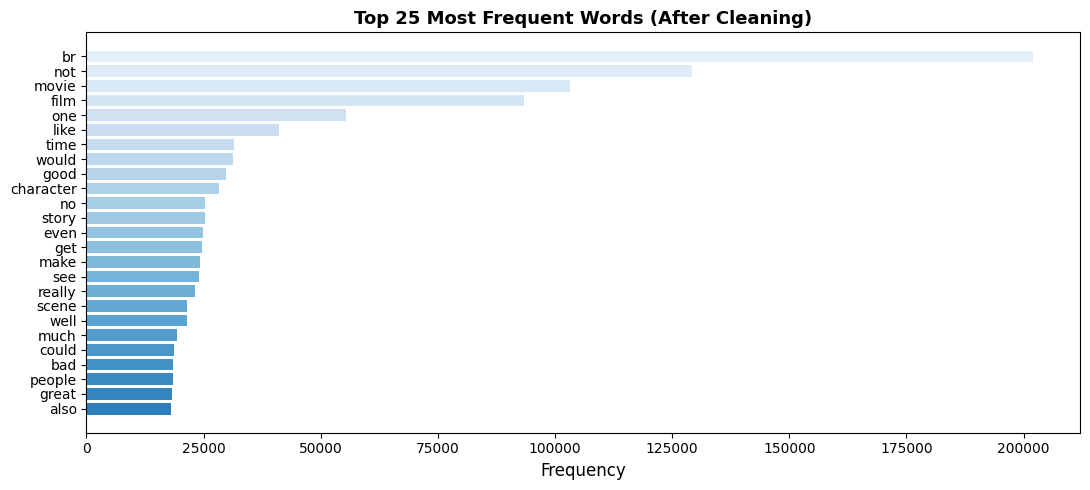

In [6]:
# Word Clouds
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
for label, ax, cmap, title in [
    (1, axes[0], "YlGn",  "Positive Reviews"),
    (0, axes[1], "OrRd",  "Negative Reviews")
]:
    text = " ".join(df_full[df_full["sentiment"] == label]["clean_review"])
    wc = WordCloud(width=700, height=350, background_color="white",
                   max_words=120, colormap=cmap).generate(text)
    ax.imshow(wc, interpolation="bilinear")
    ax.axis("off")
    ax.set_title(title, fontsize=14, fontweight="bold")

plt.suptitle("Word Clouds After Preprocessing", fontsize=16, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

# Top 25 Words
all_words = " ".join(df_full["clean_review"]).split()
freq = Counter(all_words).most_common(25)
words_f, counts_f = zip(*freq)

fig, ax = plt.subplots(figsize=(11, 5))
bars = ax.barh(list(words_f)[::-1], list(counts_f)[::-1],
               color=plt.cm.Blues_r(np.linspace(0.3, 0.9, 25)))
ax.set_xlabel("Frequency", fontsize=12)
ax.set_title("Top 25 Most Frequent Words (After Cleaning)", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()


### Tokenization & Padding

Training samples : 40,000
Test samples     : 10,000

Vocabulary size (unique words in train): 82,159
Padding length (capped at 150): 150 tokens


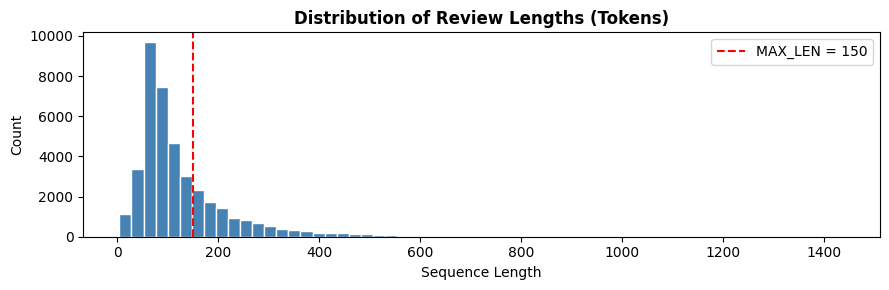


X_train_pad shape : (40000, 150)
X_test_pad  shape : (10000, 150)


In [7]:
X = df_full["clean_review"].values
y = df_full["sentiment"].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=SEED, stratify=y)

print(f"Training samples : {len(X_train):,}")
print(f"Test samples     : {len(X_test):,}")

# Tokenizer
VOCAB_SIZE = 20_000
tokenizer  = Tokenizer(num_words=VOCAB_SIZE, oov_token="<OOV>")
tokenizer.fit_on_texts(X_train)
print(f"\nVocabulary size (unique words in train): {len(tokenizer.word_index):,}")

# Sequences
train_seqs = tokenizer.texts_to_sequences(X_train)
test_seqs  = tokenizer.texts_to_sequences(X_test)

# 95th-percentile sequence length for padding
lengths = [len(s) for s in train_seqs]
MAX_LEN = min(int(np.percentile(lengths, 95)), 150)
print(f"Padding length (capped at 150): {MAX_LEN} tokens")

# Plot sequence length distribution
fig, ax = plt.subplots(figsize=(9, 3))
ax.hist(lengths, bins=60, color="steelblue", edgecolor="white")
ax.axvline(MAX_LEN, color="red", linestyle="--", label=f"MAX_LEN = {MAX_LEN}")
ax.set_xlabel("Sequence Length"); ax.set_ylabel("Count")
ax.set_title("Distribution of Review Lengths (Tokens)", fontweight="bold")
ax.legend(); plt.tight_layout(); plt.show()

# Pad
X_train_pad = pad_sequences(train_seqs, maxlen=MAX_LEN, padding="post", truncating="post")
X_test_pad  = pad_sequences(test_seqs,  maxlen=MAX_LEN, padding="post", truncating="post")

print(f"\nX_train_pad shape : {X_train_pad.shape}")
print(f"X_test_pad  shape : {X_test_pad.shape}")


### Model Building
Three models:
1. **Simple RNN** with trainable Embedding  
2. **LSTM** with trainable Embedding  
3. **LSTM** with pretrained **Word2Vec** embeddings

In [13]:
EMBED_DIM  = 64
EPOCHS     = 3
BATCH_SIZE = 256

early_stop = EarlyStopping(monitor="val_loss", patience=3,
                            restore_best_weights=True, verbose=1)
reduce_lr  = ReduceLROnPlateau(monitor="val_loss", factor=0.5,
                                patience=2, verbose=1)
CALLBACKS  = [early_stop, reduce_lr]


### Model 1 — Simple RNN

In [14]:
from tensorflow.keras.layers import Bidirectional

model1 = Sequential([
    Embedding(input_dim=VOCAB_SIZE, output_dim=EMBED_DIM, input_length=MAX_LEN),
    SpatialDropout1D(0.2),
    Bidirectional(SimpleRNN(64, dropout=0.2, recurrent_dropout=0.2)),
    Dense(32, activation="relu"),
    Dropout(0.3),
    Dense(1, activation="sigmoid")
], name="Model1_SimpleRNN")

model1.summary()

Model: "Model1_SimpleRNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_3 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d_3             │ ?                      │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_3 (Bidirectional) │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

### Model 2 — LSTM (Trainable Embedding)

In [15]:
model2 = Sequential([
    Embedding(input_dim=VOCAB_SIZE, output_dim=EMBED_DIM, input_length=MAX_LEN),
    SpatialDropout1D(0.2),
    Bidirectional(LSTM(64, dropout=0.2, recurrent_dropout=0.2)),
    Dense(32, activation="relu"),
    Dropout(0.3),
    Dense(1, activation="sigmoid")
], name="Model2_LSTM_TrainableEmb")

model2.summary()

Model: "Model2_LSTM_TrainableEmb"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_4 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d_4             │ ?                      │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_4 (Bidirectional) │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

### Model 3 — LSTM + Pretrained Word2Vec

In [16]:
#  Download Word2Vec ────────────────────────────────────────────────────
print("Downloading Word2Vec (Google News 300d)…")
try:
    w2v = gensim_api.load("word2vec-google-news-300")
    W2V_DIM = 300
    print("Word2Vec loaded.")
except Exception as e:
    print(f"Could not load Word2Vec ({e}).")
    print("   Falling back to glove-wiki-gigaword-100 (smaller).")
    try:
        w2v = gensim_api.load("glove-wiki-gigaword-100")
        W2V_DIM = 100
        print("GloVe 100d loaded.")
    except:
        w2v = None
        W2V_DIM = EMBED_DIM
        print("No pretrained embeddings available — using random init.")

# ── Build embedding matrix ───────────────────────────────────────────────
word_index = tokenizer.word_index

def build_embedding_matrix(w2v_model, vocab_size, embed_dim):
    matrix = np.zeros((vocab_size, embed_dim))
    hits, misses = 0, 0
    for word, idx in word_index.items():
        if idx >= vocab_size:
            continue
        try:
            matrix[idx] = w2v_model[word]
            hits += 1
        except KeyError:
            misses += 1
    pct = 100 * hits / max(hits + misses, 1)
    print(f"Embedding matrix: {hits:,} hits / {misses:,} misses ({pct:.1f}% coverage)")
    return matrix

if w2v is not None:
    emb_matrix = build_embedding_matrix(w2v, VOCAB_SIZE, W2V_DIM)
    emb_layer3 = Embedding(input_dim=VOCAB_SIZE, output_dim=W2V_DIM,
                           input_length=MAX_LEN, weights=[emb_matrix],
                           trainable=False)
else:
    emb_layer3 = Embedding(input_dim=VOCAB_SIZE, output_dim=EMBED_DIM,
                           input_length=MAX_LEN)
    W2V_DIM = EMBED_DIM

model3 = Sequential([
    emb_layer3,
    SpatialDropout1D(0.2),
    Bidirectional(LSTM(64, dropout=0.2, recurrent_dropout=0.2)),
    Dense(32, activation="relu"),
    Dropout(0.3),
    Dense(1, activation="sigmoid")
], name="Model3_LSTM_Word2Vec")

model3.summary()


Word2Vec loaded.
Embedding matrix: 17,529 hits / 2,470 misses (87.6% coverage)


Model: "Model3_LSTM_Word2Vec"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_5 (Embedding)         │ ?                      │     6,000,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d_5             │ ?                      │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_5 (Bidirectional) │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,000,000 (22.89 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 6,000,000 (22.89 MB)

### Model Training & Evaluation

### Training All Three Models

In [17]:
def compile_and_train(model, name):
    model.compile(
    loss="binary_crossentropy",
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),  # explicit lr
    metrics=["accuracy"]
    )
    print(f"\n{'='*55}\n Training: {name}\n{'='*55}")
    history = model.fit(
        X_train_pad, y_train,
        validation_split=0.15,
        epochs=EPOCHS,
        batch_size=BATCH_SIZE,
        callbacks=CALLBACKS,
        verbose=1
    )
    return history

h1 = compile_and_train(model1, "Model 1 — SimpleRNN")
h2 = compile_and_train(model2, "Model 2 — LSTM (trainable emb)")
h3 = compile_and_train(model3, "Model 3 — LSTM (Word2Vec)")



 Training: Model 1 — SimpleRNN
Epoch 1/3
133/133 ━━━━━━━━━━━━━━━━━━━━ 19s 72ms/step - accuracy: 0.5012 - loss: 0.7071 - val_accuracy: 0.4998 - val_loss: 0.6935 - learning_rate: 0.0010
Epoch 2/3
133/133 ━━━━━━━━━━━━━━━━━━━━ 4s 31ms/step - accuracy: 0.4984 - loss: 0.6951 - val_accuracy: 0.4953 - val_loss: 0.6934 - learning_rate: 0.0010
Epoch 3/3
133/133 ━━━━━━━━━━━━━━━━━━━━ 4s 28ms/step - accuracy: 0.4989 - loss: 0.6940 - val_accuracy: 0.4937 - val_loss: 0.6933 - learning_rate: 0.0010
Restoring model weights from the end of the best epoch: 3.

 Training: Model 2 — LSTM (trainable emb)
Epoch 1/3
133/133 ━━━━━━━━━━━━━━━━━━━━ 158s 1s/step - accuracy: 0.7379 - loss: 0.5117 - val_accuracy: 0.8762 - val_loss: 0.3042 - learning_rate: 0.0010
Epoch 2/3
133/133 ━━━━━━━━━━━━━━━━━━━━ 147s 1s/step - accuracy: 0.8805 - loss: 0.3119 - val_accuracy: 0.8860 - val_loss: 0.2855 - learning_rate: 0.0010
Epoch 3/3
133/133 ━━━━━━━━━━━━━━━━━━━━ 200s 1s/step - accuracy: 0.9131 - loss: 0.2434 - val_accuracy: 0.8

###  Training Curves

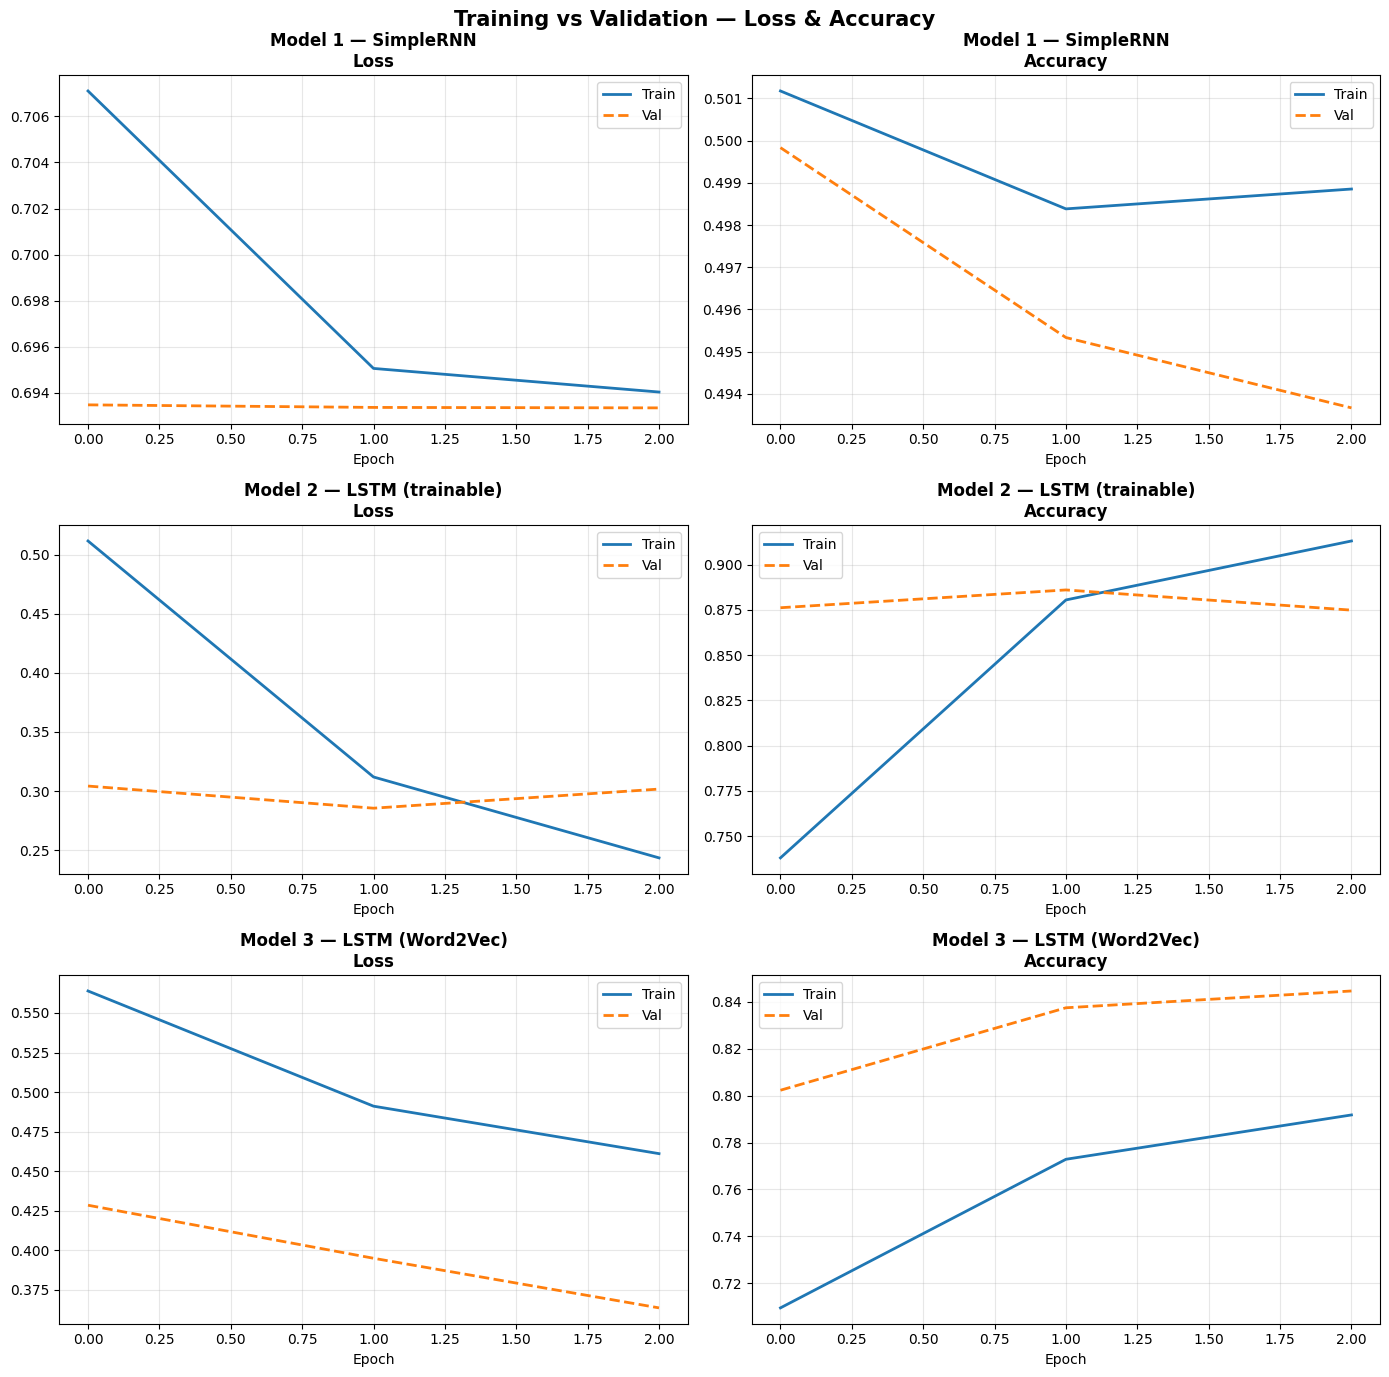

In [18]:
def plot_history(ax_loss, ax_acc, history, title):
    ax_loss.plot(history.history["loss"],     label="Train", lw=2)
    ax_loss.plot(history.history["val_loss"], label="Val",   lw=2, linestyle="--")
    ax_loss.set_title(f"{title}\nLoss", fontweight="bold")
    ax_loss.set_xlabel("Epoch"); ax_loss.legend(); ax_loss.grid(alpha=0.3)

    ax_acc.plot(history.history["accuracy"],     label="Train", lw=2)
    ax_acc.plot(history.history["val_accuracy"], label="Val",   lw=2, linestyle="--")
    ax_acc.set_title(f"{title}\nAccuracy", fontweight="bold")
    ax_acc.set_xlabel("Epoch"); ax_acc.legend(); ax_acc.grid(alpha=0.3)

fig, axes = plt.subplots(3, 2, figsize=(14, 14))
plot_history(axes[0][0], axes[0][1], h1, "Model 1 — SimpleRNN")
plot_history(axes[1][0], axes[1][1], h2, "Model 2 — LSTM (trainable)")
plot_history(axes[2][0], axes[2][1], h3, "Model 3 — LSTM (Word2Vec)")
plt.suptitle("Training vs Validation — Loss & Accuracy", fontsize=15, fontweight="bold")
plt.tight_layout()
plt.show()


###  Evaluate on Test Set

In [19]:
results = {}

def evaluate_model(model, name, y_preds_store):
    loss, acc = model.evaluate(X_test_pad, y_test, verbose=0)
    probs  = model.predict(X_test_pad, verbose=0).flatten()
    y_pred = (probs > 0.5).astype(int)
    y_preds_store[name] = y_pred

    print(f"\n{'='*55}")
    print(f" {name}")
    print(f"{'='*55}")
    print(f"  Test Loss     : {loss:.4f}")
    print(f"  Test Accuracy : {acc:.4f}\n")
    print(classification_report(y_test, y_pred,
                                 target_names=["Negative (0)", "Positive (1)"]))
    return acc, loss

y_preds = {}
acc1, loss1 = evaluate_model(model1, "Model 1 — SimpleRNN",          y_preds)
acc2, loss2 = evaluate_model(model2, "Model 2 — LSTM (trainable)",   y_preds)
acc3, loss3 = evaluate_model(model3, "Model 3 — LSTM (Word2Vec)",    y_preds)



 Model 1 — SimpleRNN
  Test Loss     : 0.6933
  Test Accuracy : 0.4985

              precision    recall  f1-score   support

Negative (0)       0.49      0.11      0.18      5000
Positive (1)       0.50      0.88      0.64      5000

    accuracy                           0.50     10000
   macro avg       0.50      0.50      0.41     10000
weighted avg       0.50      0.50      0.41     10000


 Model 2 — LSTM (trainable)
  Test Loss     : 0.3000
  Test Accuracy : 0.8794

              precision    recall  f1-score   support

Negative (0)       0.88      0.88      0.88      5000
Positive (1)       0.88      0.88      0.88      5000

    accuracy                           0.88     10000
   macro avg       0.88      0.88      0.88     10000
weighted avg       0.88      0.88      0.88     10000


 Model 3 — LSTM (Word2Vec)
  Test Loss     : 0.4394
  Test Accuracy : 0.7991

              precision    recall  f1-score   support

Negative (0)       0.75      0.89      0.82      5000
Posit

### Confusion Matrices

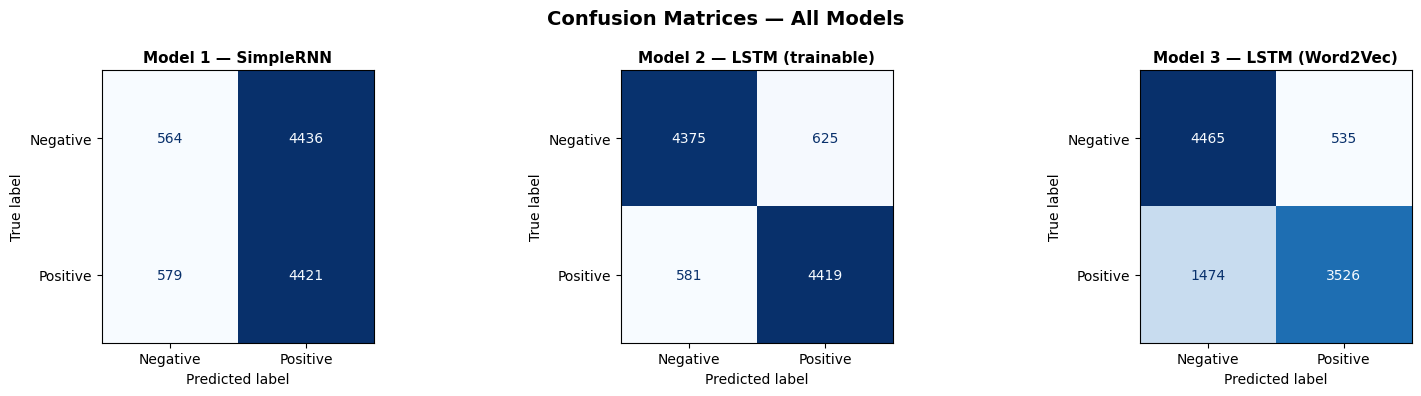

In [20]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
model_names = ["Model 1\nSimpleRNN",
               "Model 2\nLSTM (trainable)",
               "Model 3\nLSTM (Word2Vec)"]

for ax, (name, y_pred) in zip(axes, y_preds.items()):
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(cm, display_labels=["Negative", "Positive"])
    disp.plot(ax=ax, colorbar=False, cmap="Blues")
    ax.set_title(name, fontweight="bold", fontsize=11)

plt.suptitle("Confusion Matrices — All Models", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()


### Side-by-Side Model Comparison

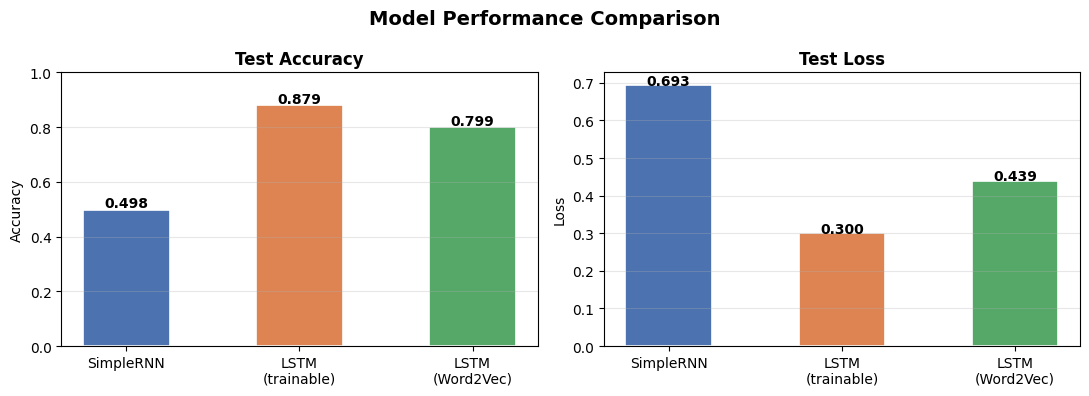


 Summary Table:


,Model,Accuracy,Loss
0,Model 1 — SimpleRNN,0.4985,0.6933
1,Model 2 — LSTM (trainable),0.8794,0.3000
2,Model 3 — LSTM (Word2Vec),0.7991,0.4394


In [21]:
labels = ["SimpleRNN", "LSTM\n(trainable)", "LSTM\n(Word2Vec)"]
accs   = [acc1, acc2, acc3]
losses = [loss1, loss2, loss3]
colors = ["#4C72B0", "#DD8452", "#55A868"]
x = np.arange(len(labels))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))

bars = ax1.bar(x, accs, color=colors, edgecolor="white", linewidth=1.2, width=0.5)
ax1.set_xticks(x); ax1.set_xticklabels(labels)
ax1.set_ylim(0, 1); ax1.set_ylabel("Accuracy")
ax1.set_title("Test Accuracy", fontweight="bold")
ax1.grid(axis="y", alpha=0.3)
for b in bars:
    ax1.text(b.get_x()+b.get_width()/2, b.get_height()+0.01,
             f"{b.get_height():.3f}", ha="center", fontweight="bold")

bars = ax2.bar(x, losses, color=colors, edgecolor="white", linewidth=1.2, width=0.5)
ax2.set_xticks(x); ax2.set_xticklabels(labels)
ax2.set_ylabel("Loss")
ax2.set_title("Test Loss", fontweight="bold")
ax2.grid(axis="y", alpha=0.3)
for b in bars:
    ax2.text(b.get_x()+b.get_width()/2, b.get_height()+0.002,
             f"{b.get_height():.3f}", ha="center", fontweight="bold")

plt.suptitle("Model Performance Comparison", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

print("\n Summary Table:")
summary = pd.DataFrame({
    "Model"   : ["Model 1 — SimpleRNN", "Model 2 — LSTM (trainable)", "Model 3 — LSTM (Word2Vec)"],
    "Accuracy": [f"{a:.4f}" for a in accs],
    "Loss"    : [f"{l:.4f}" for l in losses],
})
display(summary)


### Error Analysis

In [22]:
# Use the best model (Model 3 — LSTM + Word2Vec) for error analysis
best_preds = y_preds["Model 3 — LSTM (Word2Vec)"]
label_map  = {0: "Negative ", 1: "Positive "}

misclassified = np.where(best_preds != y_test)[0]
print(f"Total misclassified by Model 3: {len(misclassified):,} / {len(y_test):,}")
print(f"Error rate: {100*len(misclassified)/len(y_test):.2f}%\n")

false_pos = [i for i in misclassified if best_preds[i]==1 and y_test[i]==0]
false_neg = [i for i in misclassified if best_preds[i]==0 and y_test[i]==1]
print(f"False Positives (predicted Positive, actually Negative): {len(false_pos)}")
print(f"False Negatives (predicted Negative, actually Positive): {len(false_neg)}")


Total misclassified by Model 3: 2,009 / 10,000
Error rate: 20.09%

False Positives (predicted Positive, actually Negative): 535
False Negatives (predicted Negative, actually Positive): 1474


In [23]:
#  Print 3 sample misclassified reviews
print("\n" + "="*65)
print("  SAMPLE MISCLASSIFIED REVIEWS (Model 3)")
print("="*65)

samples = []
if false_pos: samples.append(("False Positive", false_pos[0]))
if false_neg: samples.append(("False Negative", false_neg[0]))
if len(false_pos) > 1: samples.append(("False Positive", false_pos[1]))
if len(false_neg) > 1 and len(samples) < 3: samples.append(("False Negative", false_neg[1]))

for i, (err_type, idx) in enumerate(samples[:3]):
    print(f"\n Example {i+1} — {err_type}")
    print(f"  Original Review  : {X_test[idx][:250]}...")
    print(f"  True Label       : {label_map[y_test[idx]]}")
    print(f"  Predicted Label  : {label_map[best_preds[idx]]}")
    print(f"  Error Type       : {err_type}")



  SAMPLE MISCLASSIFIED REVIEWS (Model 3)

 Example 1 — False Positive
  Original Review  : roy rogers roy sidekick raymond hatton rusty join teddy roosevelt rough rider soon get suspended order round killer partner eddie acuff tommy along mexican border discover creepy gold runner process notice even suspended mr rogers able get rough ride...
  True Label       : Negative 
  Predicted Label  : Positive 
  Error Type       : False Positive

 Example 2 — False Negative
  Original Review  : item less made two week shoestring budget writer director brad silberling little film shot carson ca feel like entire story improvised best sense word silberling good fortune pair veteran actor morgan freeman big project spanish actress paz vega resu...
  True Label       : Positive 
  Predicted Label  : Negative 
  Error Type       : False Negative

 Example 3 — False Positive
  Original Review  : watched teenage year movie mildly entertaining liked soul survivor gothic atmosphere party scene constan

### Error Analysis Discussion

In [24]:
# ── Extended misclassified-example viewer ──────────────────────────────────
import textwrap

def show_misclassified(indices, err_type, n=2):
    for rank, idx in enumerate(indices[:n], 1):
        prob = model3.predict(X_test_pad[idx:idx+1], verbose=0)[0][0]
        wrapped = textwrap.fill(X_test[idx], width=100)
        print(f"\n{'─'*70}")
        print(f" Example — {err_type} #{rank}")
        print(f"{'─'*70}")
        print(f" True Label       : {label_map[y_test[idx]]}")
        print(f" Predicted Label  : {label_map[best_preds[idx]]}")
        print(f" Model Confidence : {prob:.4f}  (threshold = 0.50)")
        print(f"\n Review (first 400 chars):\n")
        print(textwrap.fill(X_test[idx][:400], width=100))
        print()

show_misclassified(false_pos, 'False Positive (predicted Positive → actually Negative)', n=1)
show_misclassified(false_neg, 'False Negative (predicted Negative → actually Positive)', n=2)



──────────────────────────────────────────────────────────────────────
 Example — False Positive (predicted Positive → actually Negative) #1
──────────────────────────────────────────────────────────────────────
 True Label       : Negative 
 Predicted Label  : Positive 
 Model Confidence : 0.5212  (threshold = 0.50)

 Review (first 400 chars):

roy rogers roy sidekick raymond hatton rusty join teddy roosevelt rough rider soon get suspended
order round killer partner eddie acuff tommy along mexican border discover creepy gold runner
process notice even suspended mr rogers able get rough rider join round br br not one better roy
rogers western fighting scene look like choreographed dance rogers sings yodel ridin trail one two
relatively or


──────────────────────────────────────────────────────────────────────
 Example — False Negative (predicted Negative → actually Positive) #1
──────────────────────────────────────────────────────────────────────
 True Label       : Positive 
 Predi